# 02 Insurance Data Exploration

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `02-insurance-data-exploration.ipynb`

In [3]:
# ====================================
# Notebook 02
# Insurance Data Exploration
# ====================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [5]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [6]:
claims_df.shape

(15, 11)

In [7]:
claims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   claim_id            15 non-null     object
 1   claimant_name       15 non-null     object
 2   vehicle_vin         15 non-null     object
 3   mechanic_shop       15 non-null     object
 4   clinic_name         15 non-null     object
 5   lawyer              15 non-null     object
 6   claimant_statement  15 non-null     object
 7   police_report       15 non-null     object
 8   adjuster_notes      15 non-null     object
 9   medical_bill        15 non-null     int64 
 10  fraud_label         15 non-null     int64 
dtypes: int64(2), object(9)
memory usage: 1.4+ KB


In [8]:
claims_df.isnull().sum()

claim_id              0
claimant_name         0
vehicle_vin           0
mechanic_shop         0
clinic_name           0
lawyer                0
claimant_statement    0
police_report         0
adjuster_notes        0
medical_bill          0
fraud_label           0
dtype: int64

In [9]:
claims_df.describe()

,medical_bill,fraud_label
count,15.000000,15.000000
mean,12892.666667,0.400000
std,7987.982310,0.507093
min,1541.000000,0.000000
25%,6397.500000,0.000000
50%,11770.000000,0.000000
75%,20848.500000,1.000000
max,24392.000000,1.000000


In [10]:
claims_df["fraud_label"].value_counts()

fraud_label
0    9
1    6
Name: count, dtype: int64

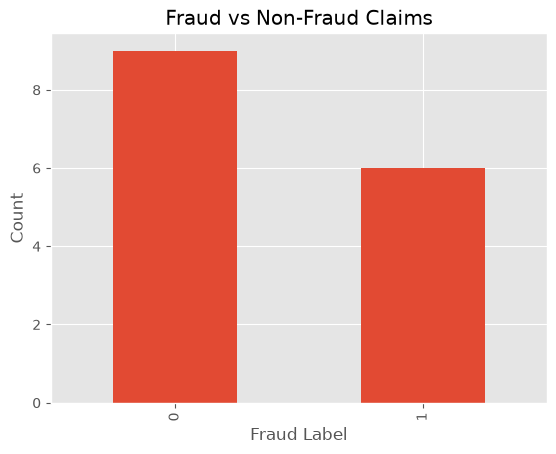

In [11]:
claims_df["fraud_label"].value_counts().plot(kind="bar")

plt.title("Fraud vs Non-Fraud Claims")

plt.xlabel("Fraud Label")

plt.ylabel("Count")

plt.show()

In [12]:
claims_df["medical_bill"].describe()

count       15.000000
mean     12892.666667
std       7987.982310
min       1541.000000
25%       6397.500000
50%      11770.000000
75%      20848.500000
max      24392.000000
Name: medical_bill, dtype: float64

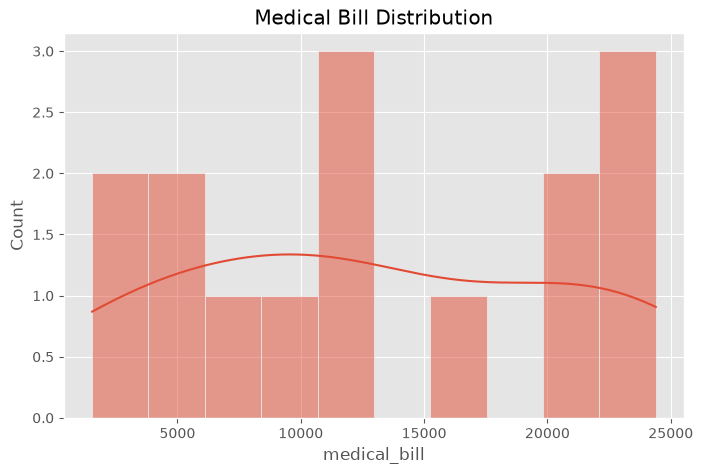

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(claims_df["medical_bill"], bins=10, kde=True)

plt.title("Medical Bill Distribution")

plt.show()

In [14]:
claims_df.groupby("fraud_label")["medical_bill"].mean()

fraud_label
0    13261.777778
1    12339.000000
Name: medical_bill, dtype: float64

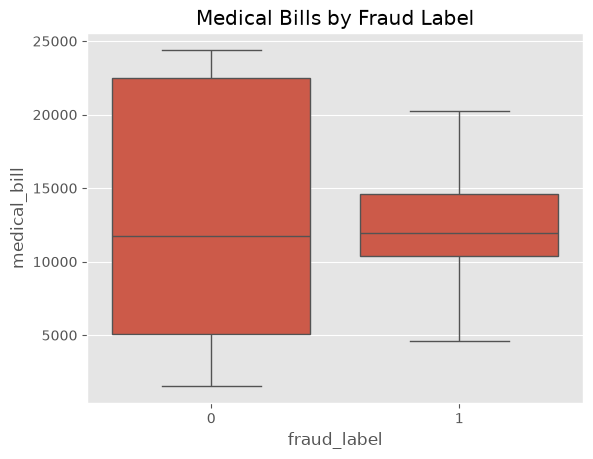

In [15]:
sns.boxplot(data=claims_df, x="fraud_label", y="medical_bill")

plt.title("Medical Bills by Fraud Label")

plt.show()

In [16]:
claims_df["mechanic_shop"].value_counts()

mechanic_shop
Rapid Auto Repair         9
Prime Vehicle Repair      2
Metro Auto Works          2
Elite Collision Center    1
Trusted Auto Garage       1
Name: count, dtype: int64

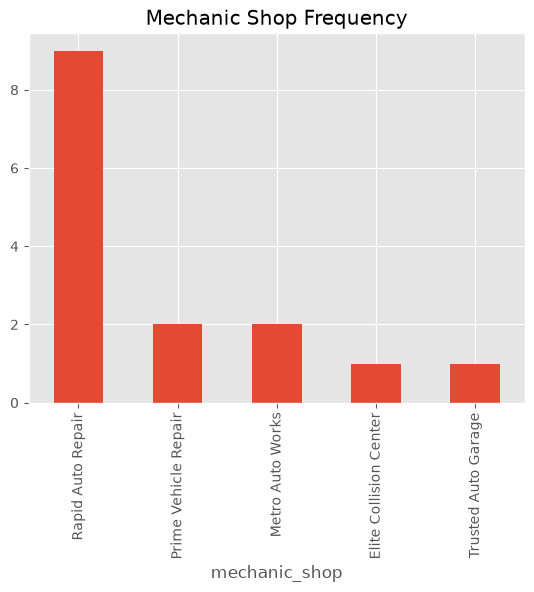

In [17]:
claims_df["mechanic_shop"].value_counts().plot(kind="bar")

plt.title("Mechanic Shop Frequency")

plt.show()

In [18]:
claims_df["clinic_name"].value_counts()

clinic_name
Care First Clinic           4
Metro Injury Clinic         4
Advanced Spine Center       4
Wellness Recovery Center    3
Name: count, dtype: int64

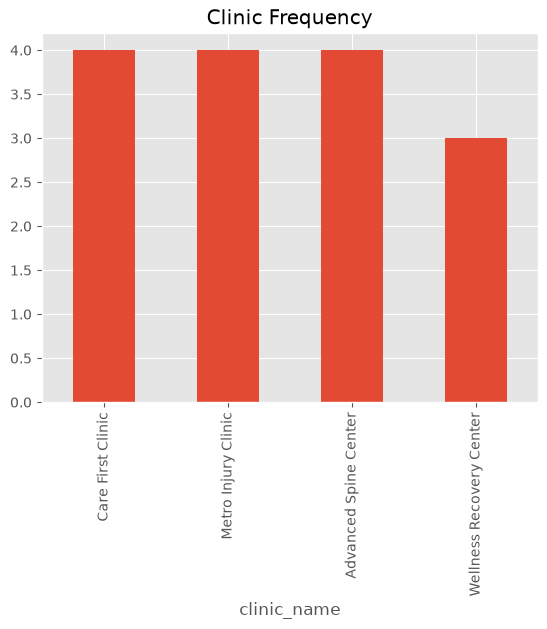

In [19]:
claims_df["clinic_name"].value_counts().plot(kind="bar")

plt.title("Clinic Frequency")

plt.show()

In [20]:
claims_df["lawyer"].value_counts()

lawyer
Smith & Associates         5
Premier Injury Law         5
Anderson Legal             2
Justice Partners           2
Accident Recovery Group    1
Name: count, dtype: int64

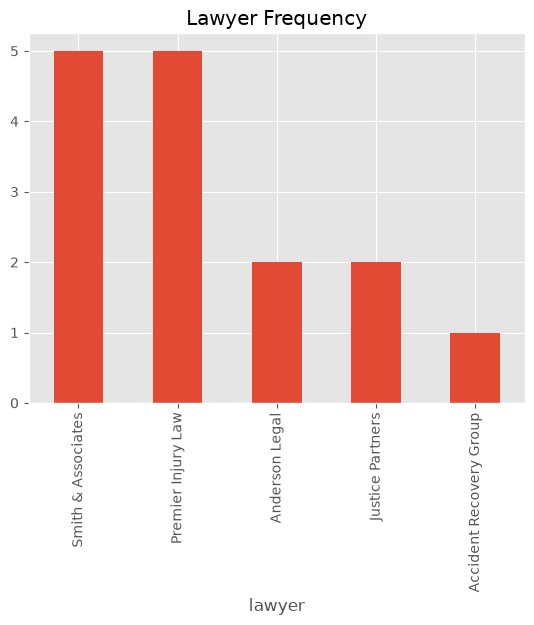

In [21]:
claims_df["lawyer"].value_counts().plot(kind="bar")

plt.title("Lawyer Frequency")

plt.show()

In [22]:
fraud_claims = claims_df[claims_df["fraud_label"] == 1]

In [23]:
fraud_claims

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
5,CLM006,Kevin Paul,cMw46708542594,Prime Vehicle Repair,Metro Injury Clinic,Smith & Associates,\n\nMy neck and lower back experienced severe ...,Witnesses confirmed another driver caused the ...,Employee raise financial.,11529,1
7,CLM008,Pamela Hayes,yfD17615912160,Rapid Auto Repair,Metro Injury Clinic,Premier Injury Law,I was traveling within the speed limit when th...,Accident report indicates claimant followed tr...,Brother they take positive apply relate.,4590,1
8,CLM009,Kendra Reyes,SVZ01756439163,Rapid Auto Repair,Metro Injury Clinic,Premier Injury Law,The driver failed to yield and collided with m...,Accident report indicates claimant followed tr...,Treatment change building interesting scene.,12350,1
9,CLM010,Julia Wilson,UsI18443206019,Rapid Auto Repair,Metro Injury Clinic,Premier Injury Law,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Way two modern another defense middle.,9982,1
10,CLM011,Patrick Harvey,leO61992562839,Rapid Auto Repair,Advanced Spine Center,Anderson Legal,\n\nMy neck and lower back experienced severe ...,Traffic camera footage supports claimant state...,Fire audience exist evening story to develop.,15357,1


In [24]:
fraud_claims["mechanic_shop"].value_counts()

mechanic_shop
Rapid Auto Repair       5
Prime Vehicle Repair    1
Name: count, dtype: int64

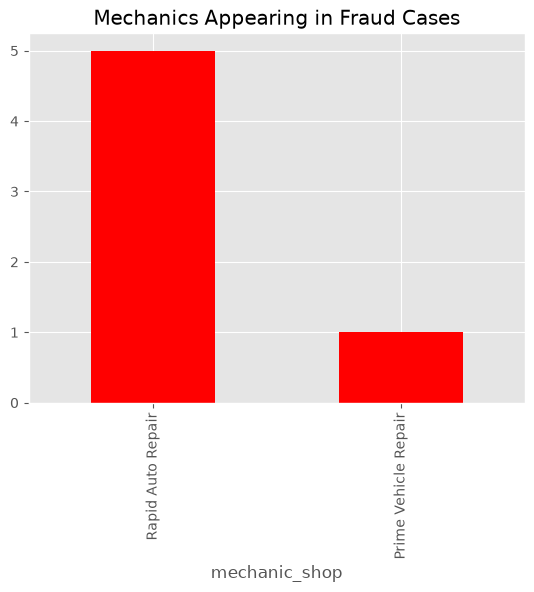

In [25]:
fraud_claims["mechanic_shop"].value_counts().plot(kind="bar", color="red")

plt.title("Mechanics Appearing in Fraud Cases")

plt.show()

In [26]:
fraud_claims["clinic_name"].value_counts()

clinic_name
Metro Injury Clinic      4
Care First Clinic        1
Advanced Spine Center    1
Name: count, dtype: int64

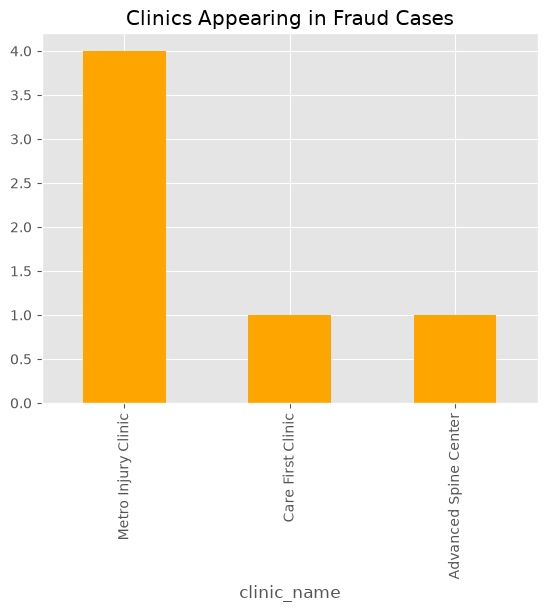

In [27]:
fraud_claims["clinic_name"].value_counts().plot(kind="bar", color="orange")

plt.title("Clinics Appearing in Fraud Cases")

plt.show()

In [28]:
fraud_claims["lawyer"].value_counts()

lawyer
Premier Injury Law    3
Justice Partners      1
Smith & Associates    1
Anderson Legal        1
Name: count, dtype: int64

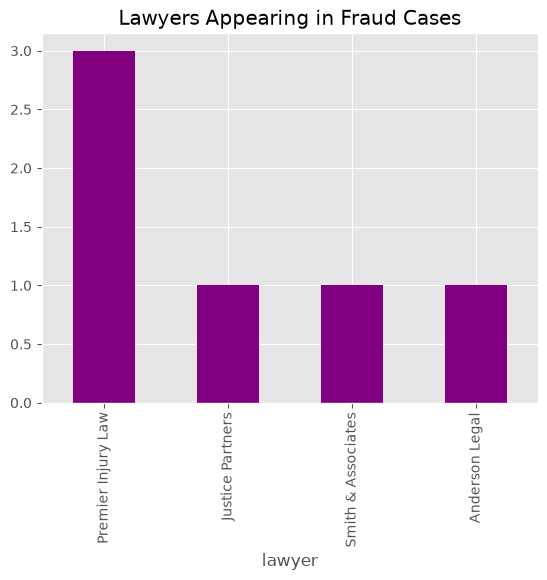

In [29]:
fraud_claims["lawyer"].value_counts().plot(kind="bar", color="purple")

plt.title("Lawyers Appearing in Fraud Cases")

plt.show()

In [30]:
entity_summary = pd.DataFrame(
    {
        "mechanic_count": claims_df.groupby("mechanic_shop").size(),
        "fraud_count": claims_df.groupby("mechanic_shop")["fraud_label"].sum(),
    }
).reset_index()

In [31]:
entity_summary

,mechanic_shop,mechanic_count,fraud_count
0,Elite Collision Center,1,0
1,Metro Auto Works,2,0
2,Prime Vehicle Repair,2,1
3,Rapid Auto Repair,9,5
4,Trusted Auto Garage,1,0


In [32]:
entity_summary["fraud_rate"] = (
    entity_summary["fraud_count"] / entity_summary["mechanic_count"]
)

In [33]:
entity_summary.sort_values(by="fraud_rate", ascending=False)

,mechanic_shop,mechanic_count,fraud_count,fraud_rate
3,Rapid Auto Repair,9,5,0.555556
2,Prime Vehicle Repair,2,1,0.500000
0,Elite Collision Center,1,0,0.000000
1,Metro Auto Works,2,0,0.000000
4,Trusted Auto Garage,1,0,0.000000


In [34]:
claims_df["statement_length"] = claims_df["claimant_statement"].astype(str).apply(len)

In [35]:
claims_df["statement_length"].describe()

count     15.000000
mean      80.333333
std       44.287481
min       54.000000
25%       56.500000
50%       66.000000
75%       73.000000
max      188.000000
Name: statement_length, dtype: float64

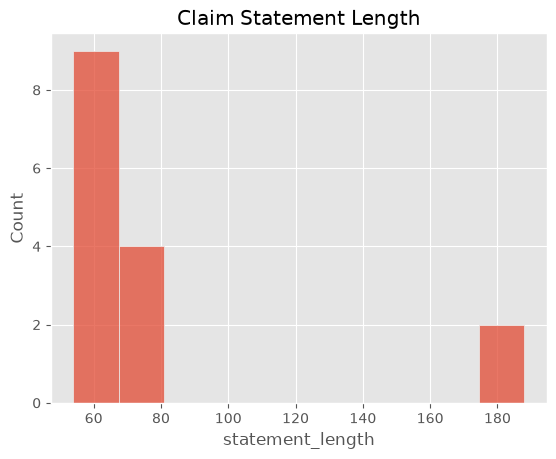

In [36]:
sns.histplot(claims_df["statement_length"], bins=10)

plt.title("Claim Statement Length")

plt.show()

In [37]:
claims_df[["claim_id", "statement_length"]].sort_values(
    by="statement_length", ascending=False
).head()

,claim_id,statement_length
5,CLM006,188
10,CLM011,188
4,CLM005,73
6,CLM007,73
9,CLM010,73


In [38]:
numeric_df = claims_df[["medical_bill", "fraud_label", "statement_length"]]

In [39]:
numeric_df.corr()

,medical_bill,fraud_label,statement_length
medical_bill,1.000000,-0.058580,0.027195
fraud_label,-0.058580,1.000000,0.464362
statement_length,0.027195,0.464362,1.000000


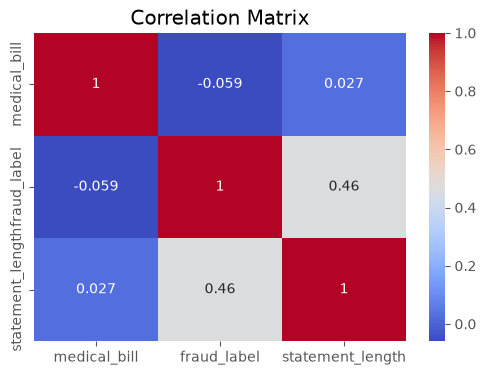

In [40]:
plt.figure(figsize=(6, 4))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [41]:
summary = {
    "total_claims": len(claims_df),
    "fraud_claims": int(claims_df["fraud_label"].sum()),
    "average_bill": round(claims_df["medical_bill"].mean(), 2),
    "unique_mechanics": claims_df["mechanic_shop"].nunique(),
    "unique_clinics": claims_df["clinic_name"].nunique(),
}

summary

{'total_claims': 15,
 'fraud_claims': 6,
 'average_bill': 12892.67,
 'unique_mechanics': 5,
 'unique_clinics': 4}

In [42]:
report_df = pd.DataFrame([summary])

In [44]:
report_df.to_csv("../reports/insurance_eda_report.csv", index=False)